In [156]:
import pandas as pd

In [107]:
df_stats = pd.read_parquet('01_numpy_dstats.parquet')

In [108]:
df_ng = pd.read_parquet('01_numpy_ng.parquet')

In [109]:
print(df_stats.tail(3).to_csv(index=False))

Name,Timestamp,CPUPerc,MemPerc,MemUsed
LB,2025-02-28 16:39:50+09:00,0.09,0.65,103.4
LB,2025-02-28 16:40:00+09:00,0.1,0.65,103.4
LB,2025-02-28 16:40:10+09:00,0.1,0.65,103.5



In [110]:
print(df_ng.head(3).to_csv(index=False))

DateTime,TPS,vuser,Errors
2025-02-28 16:11:20+09:00,20.3,21.4,0.0
2025-02-28 16:11:30+09:00,38.7,41.8,0.0
2025-02-28 16:11:40+09:00,58.2,61.6,0.0



In [113]:
# 최소 및 최대 시간 구하기
min_time = max(df_stats["Timestamp"].min(), df_ng["DateTime"].min())
max_time = min(df_stats["Timestamp"].max(), df_ng["DateTime"].max())
print(min_time, max_time)

2025-02-28 16:11:20+09:00 2025-02-28 16:21:00+09:00


In [114]:
# 시간 범위 맞추기
df_s = df_stats[(df_stats["Timestamp"] >= min_time) & (df_stats["Timestamp"] <= max_time)]
df_n = df_ng[(df_ng["DateTime"] >= min_time) & (df_ng["DateTime"] <= max_time)]

In [115]:
df_s["Timestamp"].min() == df_n["DateTime"].min()

True

In [118]:
df_s["Timestamp"].max() == df_n["DateTime"].max()

True

In [121]:
df_s.dtypes

Name                             object
Timestamp    datetime64[ns, Asia/Seoul]
CPUPerc                         float64
MemPerc                         float64
MemUsed                         float64
dtype: object

In [122]:
df_n.dtypes

DateTime    datetime64[ns, Asia/Seoul]
TPS                            float64
vuser                          float64
Errors                         float64
dtype: object

In [124]:
df_s_pivot = df_s.pivot_table(index='Timestamp', columns='Name', values=['CPUPerc', 'MemPerc', 'MemUsed'])

In [126]:
df_s_pivot.head(3)

CPUPerc              MemPerc               MemUsed  \
Name                        AGENT    API    LB   AGENT    API    LB    AGENT   
Timestamp                                                                      
2025-02-28 16:11:20+09:00   14.47   9.01  1.16   13.38  20.83  0.59  2119.68   
2025-02-28 16:11:40+09:00   17.72  14.22  1.89   13.44  21.06  0.59  2128.90   
2025-02-28 16:11:50+09:00   21.54  25.75  2.68   13.60  22.04  0.60  2155.52   

                                         
Name                         API     LB  
Timestamp                                
2025-02-28 16:11:20+09:00  53.31  93.09  
2025-02-28 16:11:40+09:00  53.92  93.27  
2025-02-28 16:11:50+09:00  56.42  95.46

In [128]:
new_columns = []
for col in df_s_pivot.columns:
    # 튜플의 두 번째 요소(예: A, B)와 첫 번째 요소(예: CPUPerc, MemPerc)를 결합
    new_column_name = f"{col[1]}_{col[0]}"
    new_columns.append(new_column_name)

In [129]:
new_columns

['AGENT_CPUPerc',
 'API_CPUPerc',
 'LB_CPUPerc',
 'AGENT_MemPerc',
 'API_MemPerc',
 'LB_MemPerc',
 'AGENT_MemUsed',
 'API_MemUsed',
 'LB_MemUsed']

In [130]:
for col in df_s_pivot.columns:
    print(col)

('CPUPerc', 'AGENT')
('CPUPerc', 'API')
('CPUPerc', 'LB')
('MemPerc', 'AGENT')
('MemPerc', 'API')
('MemPerc', 'LB')
('MemUsed', 'AGENT')
('MemUsed', 'API')
('MemUsed', 'LB')


In [133]:
df_s_pivot.columns = new_columns
df_s_pivot.reset_index(inplace=True)

In [134]:
df_s_pivot.head(5)

,Timestamp,AGENT_CPUPerc,API_CPUPerc,LB_CPUPerc,AGENT_MemPerc,API_MemPerc,LB_MemPerc,AGENT_MemUsed,API_MemUsed,LB_MemUsed
0,2025-02-28 16:11:20+09:00,14.47,9.01,1.16,13.38,20.83,0.59,2119.68,53.31,93.09
1,2025-02-28 16:11:40+09:00,17.72,14.22,1.89,13.44,21.06,0.59,2128.90,53.92,93.27
2,2025-02-28 16:11:50+09:00,21.54,25.75,2.68,13.60,22.04,0.60,2155.52,56.42,95.46
3,2025-02-28 16:12:00+09:00,24.85,27.32,2.72,13.69,22.48,0.61,2169.86,57.55,95.91
4,2025-02-28 16:12:10+09:00,20.91,34.93,3.37,13.78,21.96,0.61,2184.19,56.22,95.99


In [136]:
df_s_pivot.dtypes

Timestamp        datetime64[ns, Asia/Seoul]
AGENT_CPUPerc                       float64
API_CPUPerc                         float64
LB_CPUPerc                          float64
AGENT_MemPerc                       float64
API_MemPerc                         float64
LB_MemPerc                          float64
AGENT_MemUsed                       float64
API_MemUsed                         float64
LB_MemUsed                          float64
dtype: object

In [140]:
# JOIN
merged_df = pd.merge(df_n, df_s_pivot, left_on='DateTime', right_on='Timestamp', how='inner')
# Timestamp 컬럼은 제거
merged_df.drop('Timestamp', axis=1, inplace=True)

In [141]:
# Timestamp 컬럼은 제거
merged_df.head(3)

,DateTime,TPS,vuser,Errors,AGENT_CPUPerc,API_CPUPerc,LB_CPUPerc,AGENT_MemPerc,API_MemPerc,LB_MemPerc,AGENT_MemUsed,API_MemUsed,LB_MemUsed
0,2025-02-28 16:11:20+09:00,20.3,21.4,0.0,14.47,9.01,1.16,13.38,20.83,0.59,2119.68,53.31,93.09
1,2025-02-28 16:11:40+09:00,58.2,61.6,0.0,17.72,14.22,1.89,13.44,21.06,0.59,2128.90,53.92,93.27
2,2025-02-28 16:11:50+09:00,90.8,82.4,0.0,21.54,25.75,2.68,13.60,22.04,0.60,2155.52,56.42,95.46


In [142]:
merged_df.to_parquet('01_numpy_merged.parquet')

# Chart

In [157]:
df = pd.read_parquet('01_numpy_merged.parquet')

In [160]:
df.columns

Index(['DateTime', 'TPS', 'vuser', 'Errors', 'AGENT_CPUPerc', 'API_CPUPerc',
       'LB_CPUPerc', 'AGENT_MemPerc', 'API_MemPerc', 'LB_MemPerc',
       'AGENT_MemUsed', 'API_MemUsed', 'LB_MemUsed'],
      dtype='object')

In [158]:
print(df.describe())

              TPS        vuser     Errors  AGENT_CPUPerc  API_CPUPerc  \
count   49.000000    49.000000   49.00000      49.000000    49.000000   
mean   385.902041   606.465306  203.84898      38.424490    98.599184   
std    137.015465   324.488221  206.20292      20.161889    46.157750   
min     20.300000    21.400000    0.00000      14.470000     0.100000   
25%    354.400000   333.200000    0.00000      26.880000    57.220000   
50%    438.500000   629.200000  205.60000      33.060000   114.520000   
75%    471.900000   923.200000  367.40000      46.220000   141.350000   
max    534.000000  1000.000000  693.00000     143.760000   145.790000   

       LB_CPUPerc  AGENT_MemPerc  API_MemPerc  LB_MemPerc  AGENT_MemUsed  \
count   49.000000      49.000000    49.000000   49.000000      49.000000   
mean    18.696531      25.194286    37.740408    0.642653    3992.848367   
std     21.116034       7.881350    10.622676    0.029845    1249.086752   
min      0.080000      13.380000    20

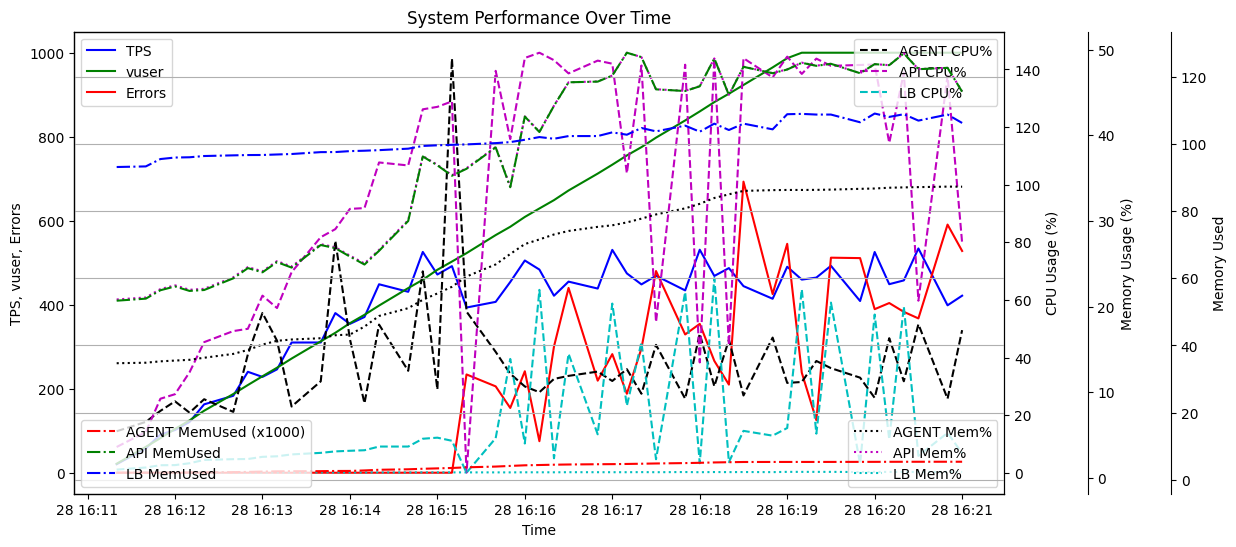

In [161]:
# 플로팅
fig, ax1 = plt.subplots(figsize=(12, 6))

# 첫 번째 Y축 (기본)
ax1.plot(df['DateTime'], df['TPS'], '-b', label="TPS")
ax1.plot(df['DateTime'], df['vuser'], '-g', label="vuser")
ax1.plot(df['DateTime'], df['Errors'], '-r', label="Errors")
ax1.set_ylabel("TPS, vuser, Errors")
ax1.legend(loc="upper left")

# 두 번째 Y축 (CPU 사용량)
ax2 = ax1.twinx()
ax2.plot(df['DateTime'], df['AGENT_CPUPerc'], '--k', label="AGENT CPU%")
ax2.plot(df['DateTime'], df['API_CPUPerc'], '--m', label="API CPU%")
ax2.plot(df['DateTime'], df['LB_CPUPerc'], '--c', label="LB CPU%")
ax2.set_ylabel("CPU Usage (%)")
ax2.legend(loc="upper right")

# 세 번째 Y축 (메모리 사용량)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))  # 보조축 위치 조정
ax3.plot(df['DateTime'], df['AGENT_MemPerc'], ':k', label="AGENT Mem%")
ax3.plot(df['DateTime'], df['API_MemPerc'], ':m', label="API Mem%")
ax3.plot(df['DateTime'], df['LB_MemPerc'], ':c', label="LB Mem%")
ax3.set_ylabel("Memory Usage (%)")
ax3.legend(loc="lower right")

# 네 번째 Y축 (메모리 사용량 - 크기 조정 필요)
ax4 = ax1.twinx()
ax4.spines["right"].set_position(("outward", 120))
ax4.plot(df['DateTime'], df['AGENT_MemUsed'] / 1000, '-.r', label="AGENT MemUsed (x1000)")
ax4.plot(df['DateTime'], df['API_MemUsed'], '-.g', label="API MemUsed")
ax4.plot(df['DateTime'], df['LB_MemUsed'], '-.b', label="LB MemUsed")
ax4.set_ylabel("Memory Used")
ax4.legend(loc="lower left")

# X축 설정
ax1.set_xlabel("Time")
plt.title("System Performance Over Time")
plt.grid()
plt.show()

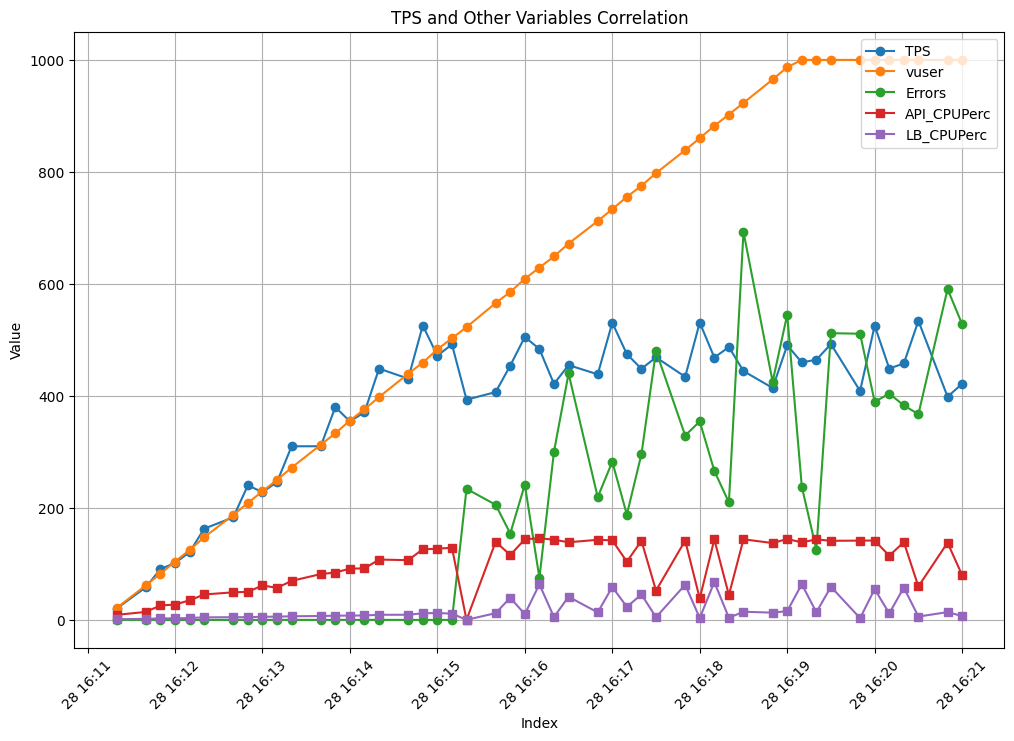

In [162]:
import matplotlib.pyplot as plt

# 변수 리스트 (TPS와 상관관계를 보고 싶은 변수들)
columns_to_plot = ['TPS', 'vuser', 'Errors', 
                    #'AGENT_CPUPerc', 'AGENT_MemPerc', 'AGENT_MemUsed',
                    'API_CPUPerc', #'API_MemPerc', 'API_MemUsed',
                    'LB_CPUPerc', #'LB_MemPerc', 'LB_MemUsed'
                  ]

markers = ['o', 's', 'D', 'p']
# markers = ['o', 's', '^', 'D', 'p', '*', '+', 'x', '|', '_']

# 선 그래프 그리기
plt.figure(figsize=(12, 8))

for i, col in enumerate(columns_to_plot):
    # 각 변수에 대해 다르게 마크 스타일을 지정
    marker = markers[i // 3]
    plt.plot(df['DateTime'], df[col], label=col, marker=marker, markersize=6)


plt.title('TPS and Other Variables Correlation')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()